# SABR Swaption Surface Calibration
Pipeline complet :
1. Chargement des discount factors → construction de la courbe des taux
2. Chargement des cotations swaptions → reconstruction de la surface de vol absolue
3. Calibration SABR (Hagan 2002) sur chaque slice (expiry × tenor)
4. Affichage des résultats + graphiques


In [1]:
# ── Paramètres ────────────────────────────────────────────────────────────────
DF_PATH  = "data/market_discount_factors.xlsx"   # chemin discount factors
SW_PATH  = "data/swaption_quotes.xlsx"           # chemin swaptions
BETA     = 0.5    # exposant CEV fixé (0 = normal, 0.5 = CIR-like, 1 = lognormal)
RESTARTS = 5      # restarts aléatoires par slice pour éviter les minima locaux


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings("ignore", category=RuntimeWarning)

from data_loader import load_discount_factors, load_full_vol_surface
from yield_curve  import YieldCurve
from sabr         import calibrate_surface, sabr_vol_vec, _parse_tenor


## 1. Construction de la courbe des taux

In [3]:
df_raw = load_discount_factors(DF_PATH)
yc     = YieldCurve(df_raw)

print(f"Date de référence : {yc.ref_date.date()}")
print(f"Nombre de piliers  : {len(df_raw)}")
print(f"Maturité min/max   : {yc._T[0]:.2f}y – {yc._T[-1]:.2f}y")


Date de référence : 2005-09-29
Nombre de piliers  : 43
Maturité min/max   : 0.00y – 50.04y


In [4]:
print("Piliers de la courbe :")
print(yc.pillar_summary().to_string(index=False))


Piliers de la courbe :
  T_years   P(0,T)  zero_rate
 0.000000 0.999942        inf
 0.010959 0.999710   0.026466
 0.021918 0.999470   0.024188
 0.087671 0.998059   0.022161
 0.169863 0.996281   0.021935
 0.473973 0.989593   0.022072
 0.709589 0.984243   0.022383
 0.978082 0.977920   0.022828
 1.224658 0.971923   0.023254
 1.471233 0.965760   0.023681
 1.726027 0.959287   0.024081
 1.975342 0.952856   0.024447
 2.221918 0.946414   0.024787
 3.005479 0.925790   0.025656
 4.005479 0.898422   0.026742
 5.005479 0.870275   0.027759
 6.005479 0.841442   0.028747
 7.002740 0.812133   0.029716
 8.008219 0.782237   0.030668
 9.008219 0.752476   0.031570
10.008219 0.723171   0.032384
11.010959 0.694473   0.033113
12.008219 0.666446   0.033793
13.005479 0.639278   0.034402
14.010959 0.612743   0.034959
15.013699 0.587727   0.035401
16.013699 0.563523   0.035816
17.013699 0.540313   0.036183
18.010959 0.518115   0.036509
19.016438 0.496713   0.036797
20.016438 0.476246   0.037061
21.016438 0.45678

In [5]:
print("Taux swap forward (exemples) :")
for exp, ten in [("1y","5y"), ("5y","5y"), ("10y","10y"), ("10y","30y")]:
    s = yc.swap_rate_from_labels(exp, ten)
    print(f"  S({exp:>4s}, {ten:>4s}) = {s:.4%}")


Taux swap forward (exemples) :
  S(  1y,   5y) = 3.0251%
  S(  5y,   5y) = 3.7578%
  S( 10y,  10y) = 4.2569%
  S( 10y,  30y) = 4.1339%


## 2. Chargement de la surface de volatilité

In [6]:
vol_surface = load_full_vol_surface(SW_PATH)
n_pairs = vol_surface[["expiry","tenor"]].drop_duplicates().shape[0]
print(f"Slices (expiry × tenor) : {n_pairs}")
print(f"Total de quotes         : {len(vol_surface)}")
vol_surface.head(12)


Slices (expiry × tenor) : 99
Total de quotes         : 259


,expiry,tenor,strike_spread_bps,vol_spread,atm_vol,implied_vol
0,10y,10y,-200,0.0639,0.144,0.2079
1,10y,10y,-100,0.0225,0.144,0.1665
2,10y,10y,-50,0.0091,0.144,0.1531
3,10y,10y,-25,0.0040,0.144,0.1480
4,10y,10y,0,0.0000,0.144,0.1440
5,10y,10y,25,-0.0031,0.144,0.1409
6,10y,10y,50,-0.0052,0.144,0.1388
7,10y,10y,100,-0.0071,0.144,0.1369
8,10y,10y,200,-0.0047,0.144,0.1393
9,10y,1y,0,0.0000,0.159,0.1590


## 3. Calibration SABR

In [7]:
print(f"Calibration SABR  (beta={BETA}, restarts={RESTARTS})\n")
surface = calibrate_surface(vol_surface, yc, beta=BETA, n_restarts=RESTARTS)


Calibration SABR  (beta=0.5, restarts=5)

  ( 10y x  10y)  F=4.2569%  alpha=0.02786  rho=-0.1458  nu=0.29804  rmse=0.0111%


c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (10y, 1y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")


  ( 10y x  20y)  F=4.1917%  alpha=0.02616  rho=-0.1679  nu=0.29654  rmse=0.0126%
  ( 10y x   2y)  F=4.1672%  alpha=0.02874  rho=+0.0128  nu=0.30307  rmse=0.0137%
  ( 10y x  30y)  F=4.1339%  alpha=0.02504  rho=-0.1732  nu=0.29617  rmse=0.0108%
  ( 10y x   5y)  F=4.2269%  alpha=0.02815  rho=-0.1321  nu=0.29539  rmse=0.0135%


c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (10y, 3y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (10y, 4y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (10y, 7y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (15y, 10y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")

  ( 20y x  10y)  F=4.0931%  alpha=0.02438  rho=-0.1593  nu=0.24431  rmse=0.0122%


...

c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (5y, 1y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")


  (  5y x   2y)  F=3.5200%  alpha=0.03336  rho=+0.0270  nu=0.34259  rmse=0.0169%
  (  5y x  30y)  F=4.0524%  alpha=0.02761  rho=-0.1391  nu=0.33453  rmse=0.0142%


c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (5y, 3y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (5y, 4y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")


  (  5y x   5y)  F=3.7578%  alpha=0.03184  rho=-0.0935  nu=0.34522  rmse=0.0123%


c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (5y, 7y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (7y, 10y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (7y, 1y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\S2\Structure par termes de taux\SABR 2\sabr.py:312: UserWarning: Too few data points for (7y, 20y), skipping.
  warnings.warn(f"Too few data points for ({expiry_str}, {tenor_str}), skipping.")
c:

## 4. Résultats — paramètres calibrés

In [8]:
summary = surface.summary()
summary


,expiry,tenor,F,alpha,beta,rho,nu,rmse_%
0,5y,2y,0.035200,0.033363,0.5,0.026951,0.342589,0.016902
1,5y,5y,0.037578,0.031838,0.5,-0.093496,0.345215,0.012306
2,5y,10y,0.039689,0.030460,0.5,-0.106024,0.343447,0.014675
3,5y,20y,0.040792,0.028610,0.5,-0.125104,0.340625,0.016733
4,5y,30y,0.040524,0.027611,0.5,-0.139149,0.334525,0.014186
5,10y,2y,0.041672,0.028737,0.5,0.012833,0.303067,0.013666
6,10y,5y,0.042269,0.028148,0.5,-0.132093,0.295395,0.013515
7,10y,10y,0.042569,0.027859,0.5,-0.145821,0.298045,0.011061
8,10y,20y,0.041917,0.026160,0.5,-0.167895,0.296542,0.012570
9,10y,30y,0.041339,0.025036,0.5,-0.173220,0.296172,0.010847


In [9]:
for col, label in [("alpha","α (alpha)"), ("rho","ρ (rho)"), ("nu","ν (nu)"), ("rmse_%","RMSE (%)")]:
    pivot = summary.pivot(index="expiry", columns="tenor", values=col)
    print(f"\n── {label} ──")
    print(pivot.to_string())



── α (alpha) ──
tenor        10y       20y        2y       30y        5y
expiry                                                  
10y     0.027859  0.026160  0.028737  0.025036  0.028148
20y     0.024377  0.022429  0.024606  0.021933  0.024618
30y     0.023443  0.022199  0.023453  0.020249  0.023239
5y      0.030460  0.028610  0.033363  0.027611  0.031838

── ρ (rho) ──
tenor        10y       20y        2y       30y        5y
expiry                                                  
10y    -0.145821 -0.167895  0.012833 -0.173220 -0.132093
20y    -0.159289 -0.199695 -0.103358 -0.197966 -0.151280
30y    -0.157897 -0.150739 -0.093733  0.035022 -0.138015
5y     -0.106024 -0.125104  0.026951 -0.139149 -0.093496

── ν (nu) ──
tenor        10y       20y        2y       30y        5y
expiry                                                  
10y     0.298045  0.296542  0.303067  0.296172  0.295395
20y     0.244309  0.243170  0.248308  0.243576  0.245127
30y     0.202858  0.204283  0.202667  0.11

## 5. Heatmaps des paramètres

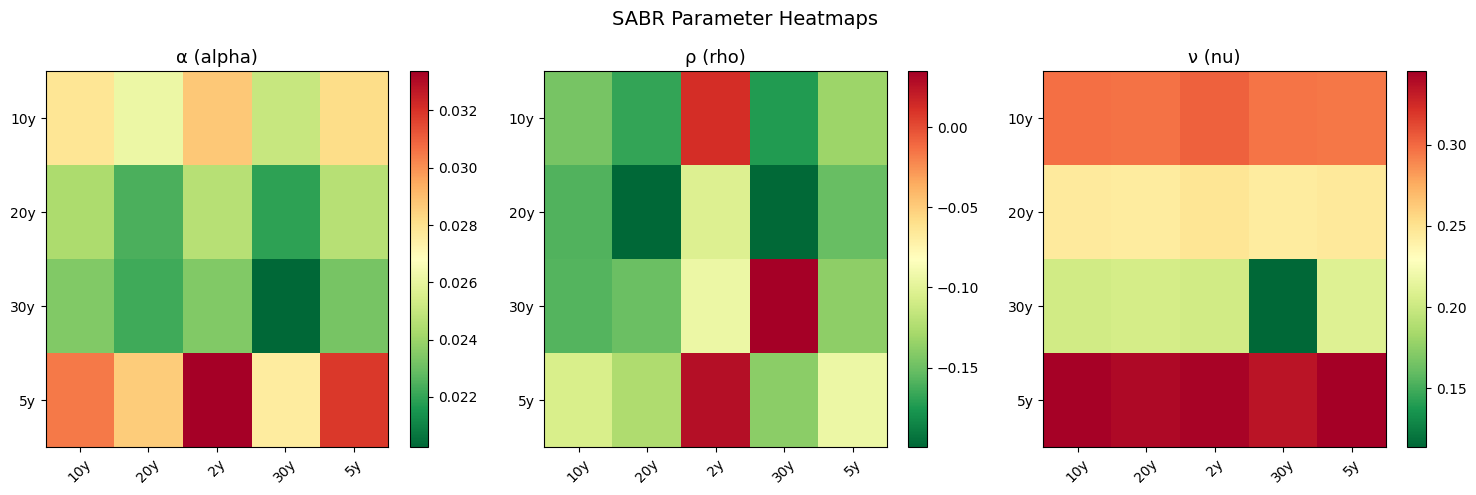

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, label in zip(
    axes,
    ["alpha", "rho", "nu"],
    ["α (alpha)", "ρ (rho)", "ν (nu)"],
):
    pivot = summary.pivot(index="expiry", columns="tenor", values=col)
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(label, fontsize=13)
    plt.colorbar(im, ax=ax)

fig.suptitle("SABR Parameter Heatmaps", fontsize=14)
fig.tight_layout()
plt.show()


## 6. Smiles de volatilité — marché vs modèle SABR

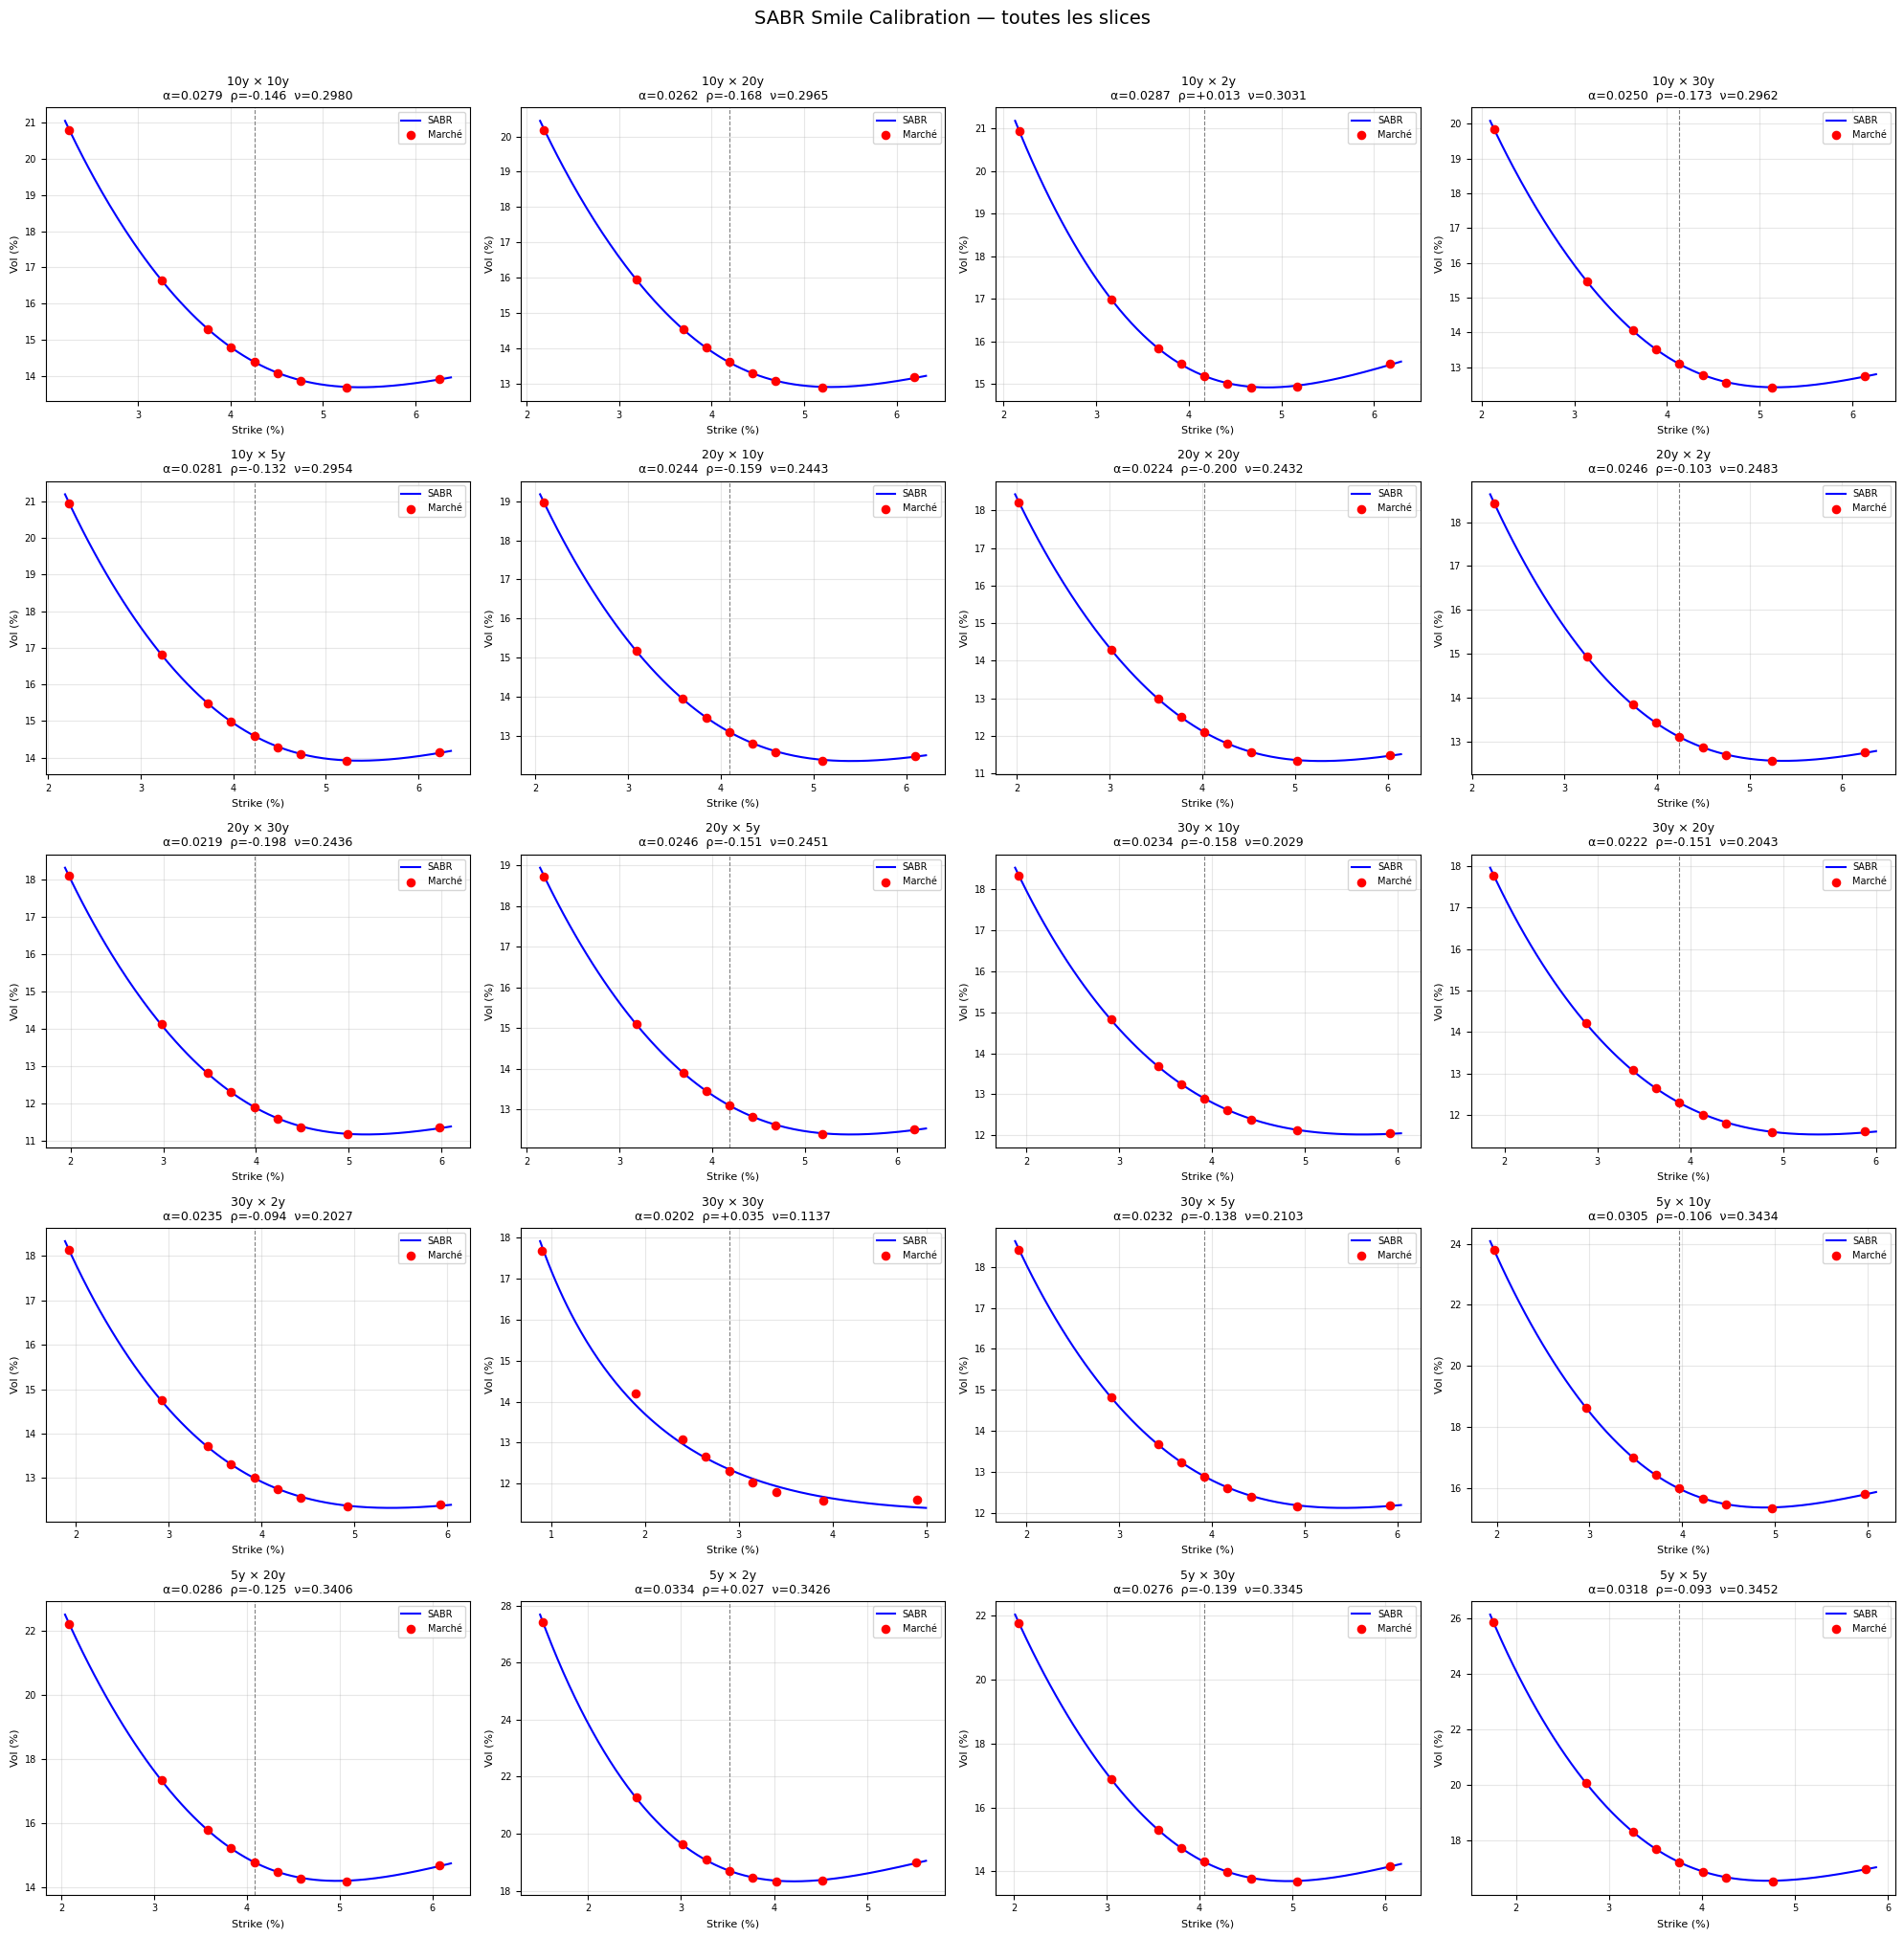

In [11]:
pairs = list(surface.results.keys())
ncols = 4
nrows = -(-len(pairs) // ncols)   # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes_flat = axes.flatten()

for ax, (expiry_str, tenor_str) in zip(axes_flat, pairs):
    T   = _parse_tenor(expiry_str)
    ten = _parse_tenor(tenor_str)
    F   = surface.forward_rates[(expiry_str, tenor_str)]
    p   = surface.results[(expiry_str, tenor_str)]

    mkt = vol_surface[
        (vol_surface["expiry"] == expiry_str) &
        (vol_surface["tenor"]  == tenor_str)
    ].copy()
    mkt["K"] = F + mkt["strike_spread_bps"] / 10_000.0

    K_grid     = np.linspace(mkt["K"].min() * 0.98, mkt["K"].max() * 1.02, 200)
    model_vols = sabr_vol_vec(F, K_grid, T, p.alpha, p.beta, p.rho, p.nu)

    ax.plot(K_grid * 100, model_vols * 100, "b-", lw=1.5, label="SABR")
    ax.scatter(mkt["K"] * 100, mkt["implied_vol"] * 100,
               color="red", zorder=5, s=35, label="Marché")
    ax.axvline(F * 100, ls="--", color="grey", lw=0.8)
    ax.set_title(f"{expiry_str} × {tenor_str}\nα={p.alpha:.4f}  ρ={p.rho:+.3f}  ν={p.nu:.4f}",
                 fontsize=9)
    ax.set_xlabel("Strike (%)", fontsize=8)
    ax.set_ylabel("Vol (%)", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

# Masquer les axes vides
for ax in axes_flat[len(pairs):]:
    ax.set_visible(False)

fig.suptitle("SABR Smile Calibration — toutes les slices", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()


## 7. Smile individuel (modifier expiry / tenor)

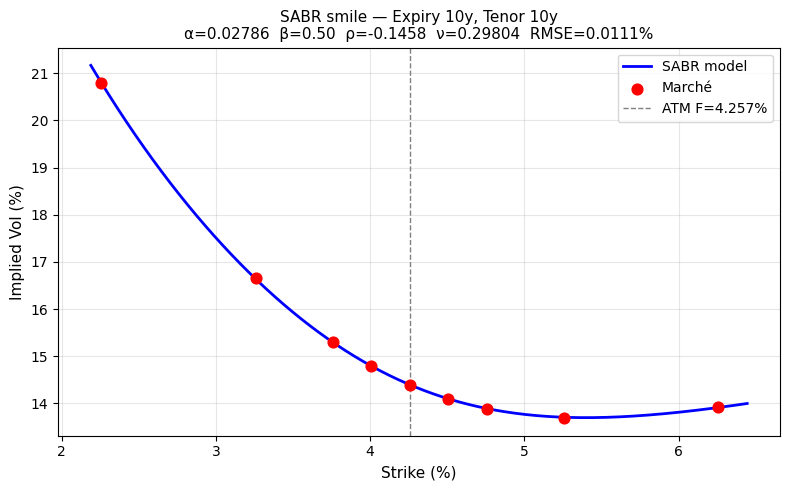


Forward rate F = 4.2569%
Paramètres SABR : alpha=0.027859, beta=0.5, rho=-0.145821, nu=0.298045
RMSE            : 0.0111%


In [12]:
# ── Choisir une slice ─────────────────────────────────────────────────────────
EXPIRY = "10y"   # options : 5y, 10y, 20y, 30y
TENOR  = "10y"   # options : 2y, 5y, 10y, 20y, 30y
# ─────────────────────────────────────────────────────────────────────────────

T   = _parse_tenor(EXPIRY)
ten = _parse_tenor(TENOR)
F   = surface.forward_rates[(EXPIRY, TENOR)]
p   = surface.results[(EXPIRY, TENOR)]

mkt = vol_surface[
    (vol_surface["expiry"] == EXPIRY) &
    (vol_surface["tenor"]  == TENOR)
].copy()
mkt["K"] = F + mkt["strike_spread_bps"] / 10_000.0

K_grid     = np.linspace(mkt["K"].min() * 0.97, mkt["K"].max() * 1.03, 300)
model_vols = sabr_vol_vec(F, K_grid, T, p.alpha, p.beta, p.rho, p.nu)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_grid * 100, model_vols * 100, "b-", lw=2, label="SABR model")
ax.scatter(mkt["K"] * 100, mkt["implied_vol"] * 100,
           color="red", zorder=5, s=60, label="Marché")
ax.axvline(F * 100, ls="--", color="grey", lw=1, label=f"ATM F={F:.3%}")
ax.set_xlabel("Strike (%)", fontsize=11)
ax.set_ylabel("Implied Vol (%)", fontsize=11)
ax.set_title(
    f"SABR smile — Expiry {EXPIRY}, Tenor {TENOR}\n"
    f"α={p.alpha:.5f}  β={p.beta:.2f}  ρ={p.rho:+.4f}  ν={p.nu:.5f}  "
    f"RMSE={p.rmse*100:.4f}%",
    fontsize=11
)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\nForward rate F = {F:.4%}")
print(f"Paramètres SABR : alpha={p.alpha:.6f}, beta={p.beta}, rho={p.rho:.6f}, nu={p.nu:.6f}")
print(f"RMSE            : {p.rmse*100:.4f}%")
